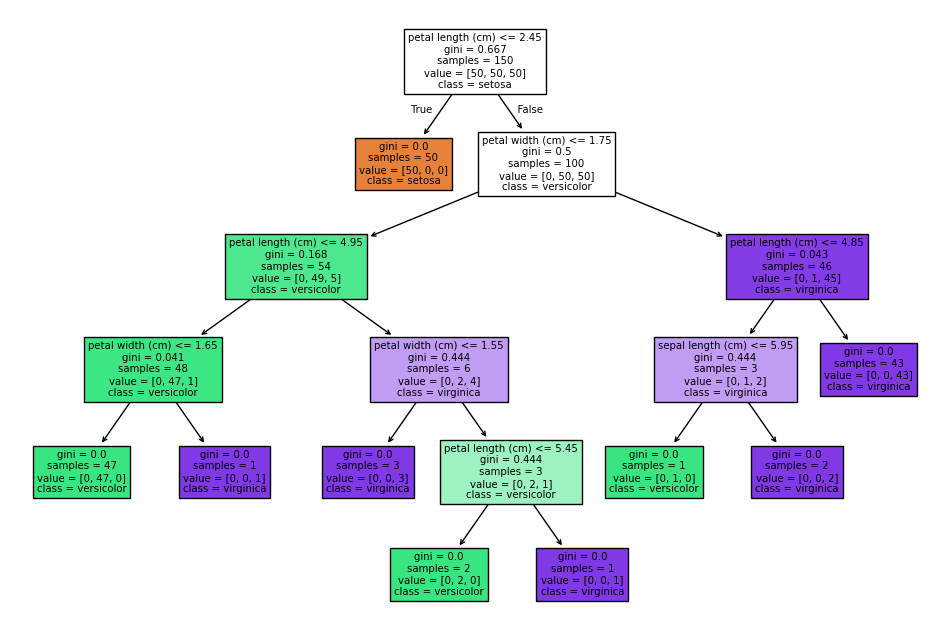

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

model = DecisionTreeClassifier(random_state=42)

model.fit(X, y)

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

Question 2: Compare Gini and Entropy

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

print(
    "Gini Accuracy:",
    accuracy_score(y_test, gini_pred)
)

print(
    "Entropy Accuracy:",
    accuracy_score(y_test, entropy_pred)
)

Gini Accuracy: 1.0
Entropy Accuracy: 1.0


Question 3: Limit Tree Depth to 2

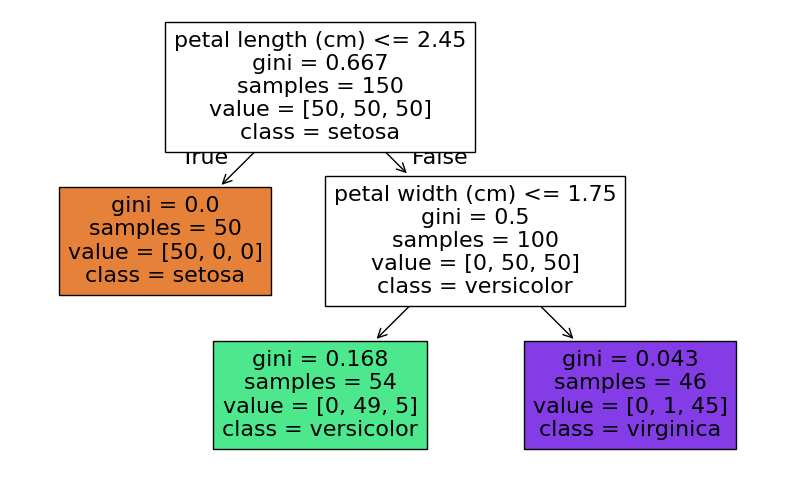

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

model.fit(X, y)

plt.figure(figsize=(10, 6))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

Question 4: Feature Importance

In [4]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

iris = load_iris()

X = iris.data
y = iris.target

model = DecisionTreeClassifier(random_state=42)

model.fit(X, y)

importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
2  petal length (cm)    0.564056
3   petal width (cm)    0.422611
0  sepal length (cm)    0.013333
1   sepal width (cm)    0.000000


Question 5: Interpret the First Three Splits

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

iris = load_iris()

X = iris.data
y = iris.target

model = DecisionTreeClassifier(random_state=42)

model.fit(X, y)

tree_rules = export_text(
    model,
    feature_names=list(iris.feature_names)
)

print(tree_rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2

